In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df=pd.read_csv('wine_data.csv',usecols=[0,1,2])
df.columns=['Class label','Alcohol','Malic Acid']

In [22]:
df

,Class label,Alcohol,Malic Acid
0,1,13.20,1.78
1,1,13.16,2.36
2,1,14.37,1.95
3,1,13.24,2.59
4,1,14.20,1.76
...,...,...,...
172,3,13.71,5.65
173,3,13.40,3.91
174,3,13.27,4.28
175,3,13.17,2.59


In [23]:
from sklearn.model_selection import train_test_split
X_train , X_test,y_train,y_test=train_test_split(df.iloc[:,1:],
                                                df['Class label'],
                                                test_size=0.3,
                                                random_state=0)

In [24]:
X_train

,Alcohol,Malic Acid
22,12.85,1.60
108,11.61,1.35
174,13.27,4.28
144,13.16,3.57
71,13.49,1.66
...,...,...
103,12.51,1.73
67,13.34,0.94
117,12.77,3.43
47,14.10,2.02


In [25]:
from sklearn.preprocessing import MinMaxScaler
scale=MinMaxScaler()
scale.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](2,)","[14.75, 5.8 ]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](2,)","[11.03, 0.89]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](2,)","[3.72,4.91]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Alcohol','Malic Acid']"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](2,)","[-2.97,-0.18]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,123


In [26]:
X_train_scaled=scale.transform(X_train)
X_test_scaled=scale.transform(X_test)

In [27]:
x_train=pd.DataFrame(X_train_scaled,columns=X_train.columns)
x_test=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [28]:
x_train


,Alcohol,Malic Acid
0,0.489247,0.144603
1,0.155914,0.093686
2,0.602151,0.690428
3,0.572581,0.545825
4,0.661290,0.156823
...,...,...
118,0.397849,0.171079
119,0.620968,0.010183
120,0.467742,0.517312
121,0.825269,0.230143


In [29]:
x_test

,Alcohol,Malic Acid
0,0.680108,0.171079
1,0.473118,0.362525
2,0.306452,0.114053
3,0.857527,0.164969
4,0.225806,0.696538
5,0.373656,0.720978
6,1.021505,0.152749
7,0.357527,0.598778
8,0.454301,0.175153
9,0.260753,0.126273


In [30]:
X_train.describe()

,Alcohol,Malic Acid
count,123.000000,123.000000
mean,12.975854,2.331951
std,0.780806,1.168503
min,11.030000,0.890000
25%,12.370000,1.560000
50%,13.050000,1.830000
75%,13.625000,3.075000
max,14.750000,5.800000


In [31]:
x_train.describe()

,Alcohol,Malic Acid
count,123.000000,123.000000
mean,0.523079,0.293676
std,0.209894,0.237984
min,0.000000,0.000000
25%,0.360215,0.136456
50%,0.543011,0.191446
75%,0.697581,0.445010
max,1.000000,1.000000


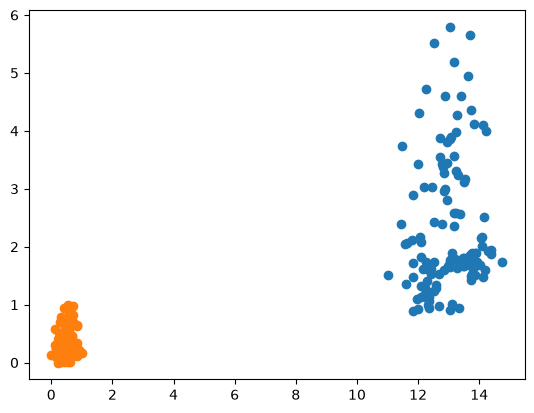

In [35]:

plt.scatter(x=X_train['Alcohol'],y=X_train['Malic Acid'])
plt.scatter(x=x_train['Alcohol'],y=x_train['Malic Acid'])

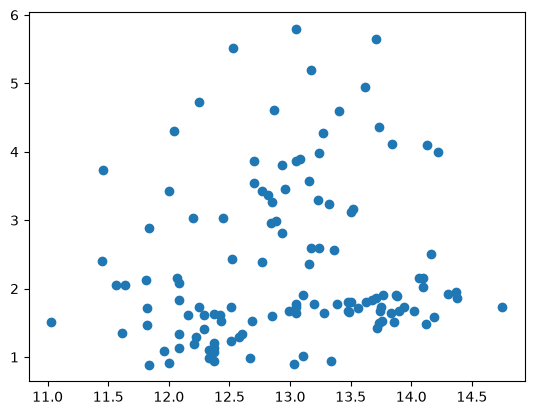

In [36]:

plt.scatter(x=X_train['Alcohol'],y=X_train['Malic Acid'])


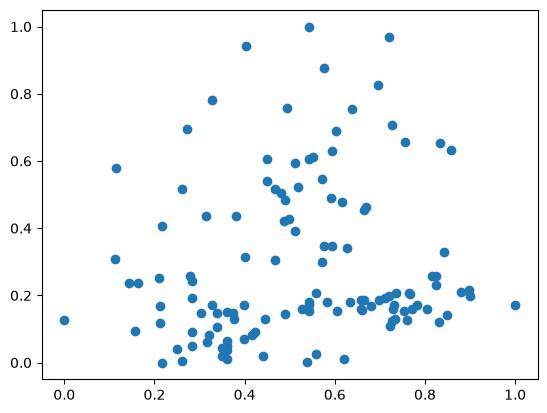

In [37]:
plt.scatter(x=x_train['Alcohol'],y=x_train['Malic Acid'])

C:\Users\User\AppData\Local\Temp\ipykernel_1580\1675461257.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Alcohol'],hist=False)
C:\Users\User\AppData\Local\Temp\ipykernel_1580\1675461257.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Malic Acid'],his

<Axes: xlabel='Malic Acid', ylabel='Density'>

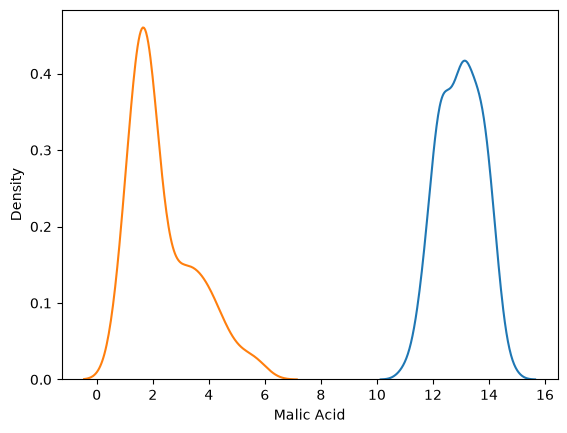

In [39]:
sns.distplot(X_train['Alcohol'],hist=False)
sns.distplot(X_train['Malic Acid'],hist=False)

C:\Users\User\AppData\Local\Temp\ipykernel_1580\2174275057.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Alcohol'],hist=False)
C:\Users\User\AppData\Local\Temp\ipykernel_1580\2174275057.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Malic Acid'],his

<Axes: xlabel='Malic Acid', ylabel='Density'>

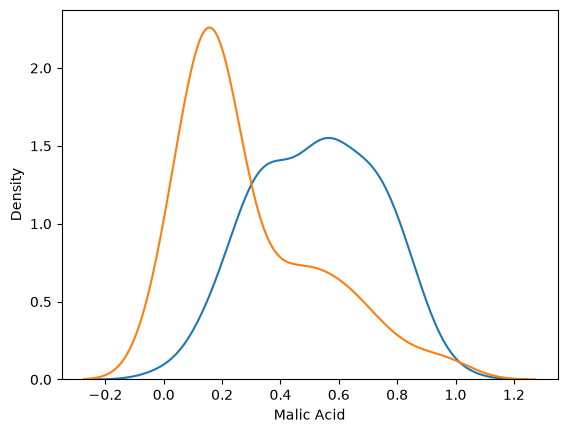

In [40]:
sns.distplot(x_train['Alcohol'],hist=False)
sns.distplot(x_train['Malic Acid'],hist=False)